In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score

In [157]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [158]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [159]:
df.duplicated().sum()

np.int64(0)

In [160]:
# Outliers using IQR method
Q1 = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].quantile(0.25)
Q3 = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] < (Q1 - 1.5 * IQR)) | (df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] > (Q3 + 1.5 * IQR))).sum()
print("Number of outliers in each numerical column:\n", outliers)


Number of outliers in each numerical column:
 Age                       0
Annual Income (k$)        2
Spending Score (1-100)    0
dtype: int64


In [161]:
# Remove outliers
df = df[~((df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] < (Q1 - 1.5 * IQR)) | (df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] > (Q3 + 1.5 * IQR))).any(axis=1)]


In [162]:
# Again check for outliers
Q1_clean = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].quantile(0.25)
Q3_clean = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].quantile(0.75)
IQR_clean = Q3_clean - Q1_clean
outliers_clean = ((df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] < (Q1_clean - 1.5 * IQR_clean)) | (df_clean[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] > (Q3_clean + 1.5 * IQR_clean))).sum()
print("Number of outliers in each numerical column after removal:\n", outliers_clean)

Number of outliers in each numerical column after removal:
 Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


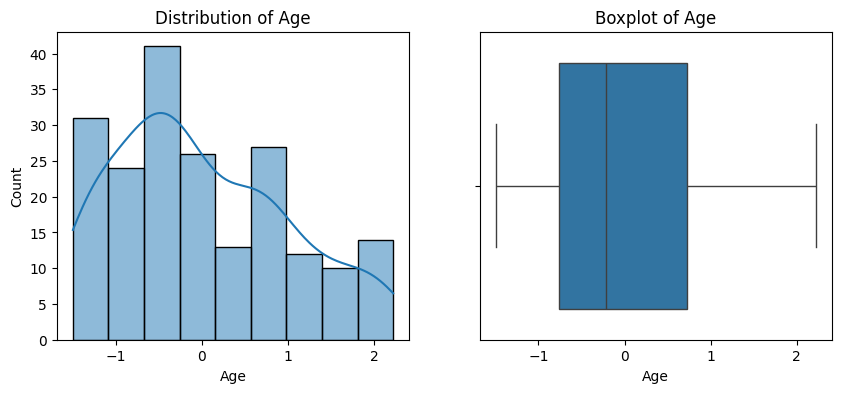

Skewness of Age: 0.47028733799761446



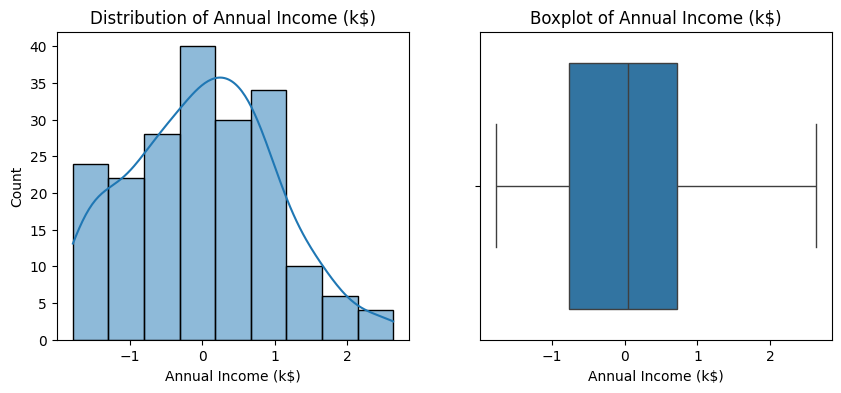

Skewness of Annual Income (k$): 0.17426672406498636



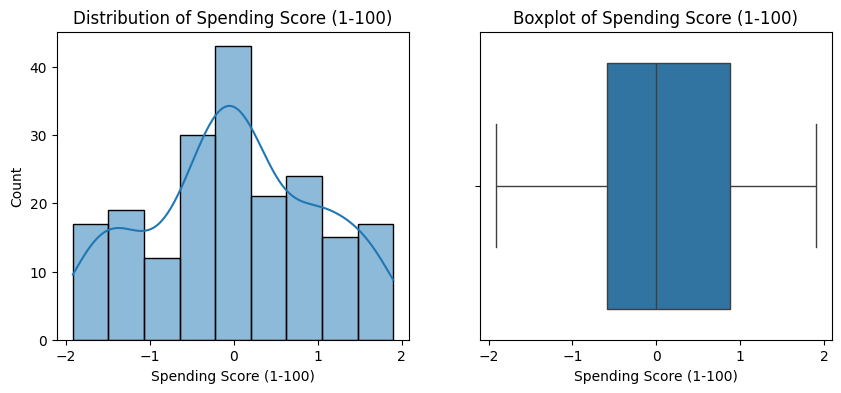

Skewness of Spending Score (1-100): -0.048346484679148635



In [163]:
# Data Distribution and Skewness
numerical_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for feature in numerical_features:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df_clean[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_clean[feature])
    plt.title(f'Boxplot of {feature}')
    
    plt.show()
    skewness = df_clean[feature].skew()
    print(f'Skewness of {feature}: {skewness}\n')
    

In [164]:
# Label Encoding
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [165]:
# Standardization
scaler = StandardScaler()
numerical_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,-1.425414,-1.779171,-0.435989
1,2,1,-1.282367,-1.779171,1.199413
2,3,0,-1.353890,-1.739447,-1.720949
3,4,0,-1.139319,-1.739447,1.043661
4,5,0,-0.567131,-1.699723,-0.397051


In [166]:
# Selecting features for clustering
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']]
# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
# Fit on the feature matrix (not the entire df)
kmeans.fit(features)
df['Cluster'] = kmeans.labels_




In [167]:
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

df['Segment'] = df['Cluster'].map({
    0: 'Young Spenders',
    1: 'Wealthy Savers',
    2: 'Mid-income Regulars'
})


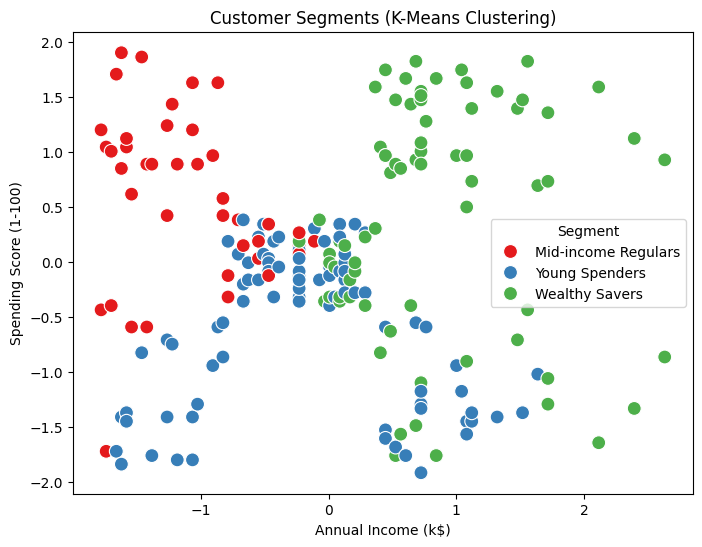

In [168]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Segment',  # use mapped segment names so legend shows names
    data=df,
    palette='Set1',
    s=100
)
plt.title("Customer Segments (K-Means Clustering)")
plt.legend(title='Segment')
plt.show()

In [169]:
print(kmeans.inertia_)

348.70095757263175


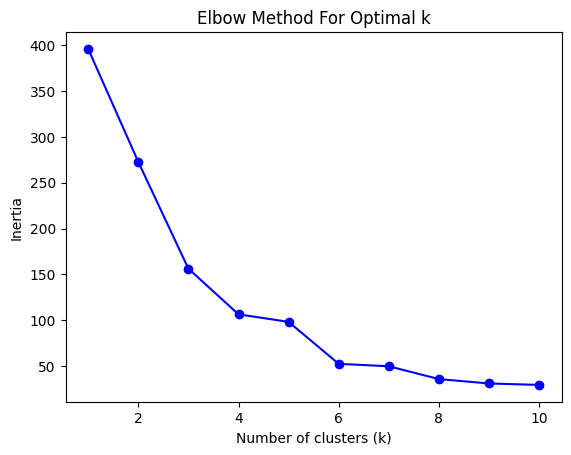

In [170]:
import matplotlib.pyplot as plt

inertia = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
    inertia.append(km.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()


In [171]:
from sklearn.metrics import silhouette_score

score = silhouette_score(df[['Annual Income (k$)', 'Spending Score (1-100)']], kmeans.labels_)
print("Silhouette Score:", score)


Silhouette Score: 0.16706995115529502
